## CONTRASTE

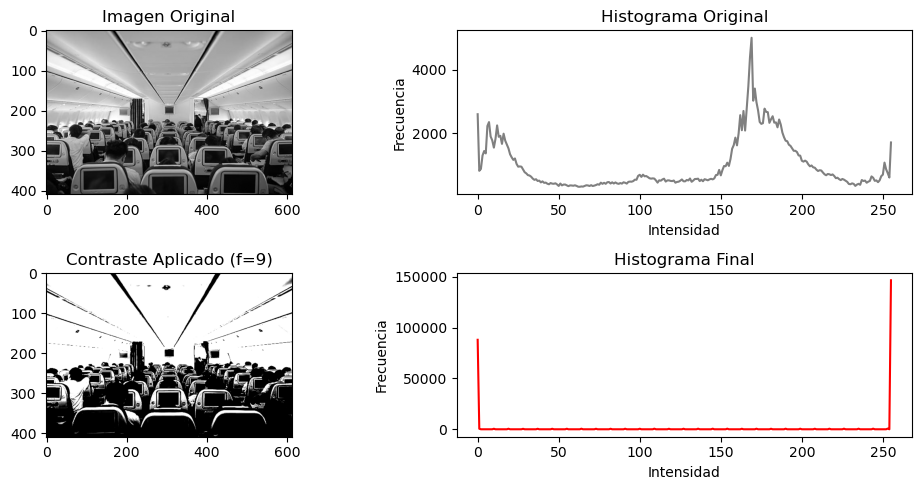

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def contraste(img, factor=1.0):
    img = img.astype(np.float32)
    media = np.mean(img)
    img_contraste = media + (img - media) * factor
    img_contraste = np.clip(img_contraste, 0, 255).astype(np.uint8)
    return img_contraste

img = cv2.imread('imagen1.jpg', 0)
contrast = 9
img_fin = contraste(img, contrast)
#### Cálculo de histogramas
histograma_ori = cv2.calcHist([img], [0], None, [256], [0, 256])
histograma_new = cv2.calcHist([img_fin], [0], None, [256], [0, 256])
####

plt.figure(figsize=(10, 5))

plt.subplot(221)
plt.imshow(img, cmap='gray')
plt.title('Imagen Original')

plt.subplot(222)
plt.plot(histograma_ori, color='gray')
plt.xlabel('Intensidad')
plt.ylabel('Frecuencia')
plt.title('Histograma Original')

plt.subplot(223)
plt.imshow(img_fin, cmap='gray')
plt.title(f'Contraste Aplicado (f={contrast})')

plt.subplot(224)
plt.plot(histograma_new, color='red')
plt.xlabel('Intensidad')
plt.ylabel('Frecuencia')
plt.title('Histograma Final')

plt.tight_layout()
plt.show()

## EJERCICIO 1


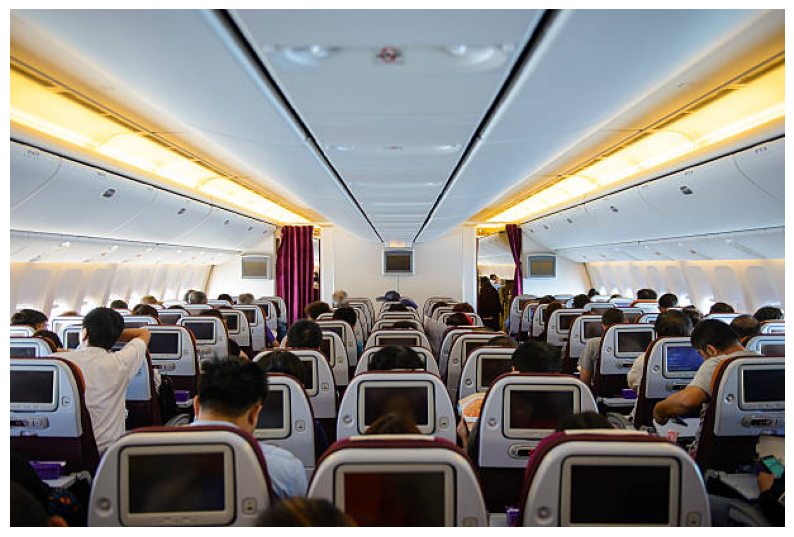

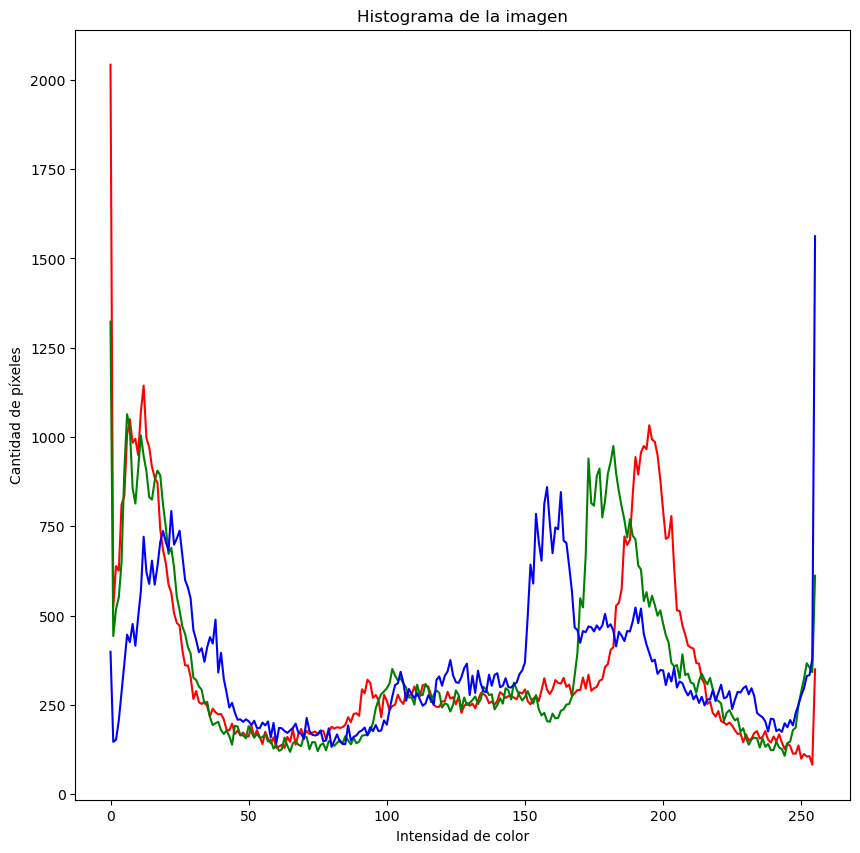

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 

image = cv2.imread('imagen1.jpg')

imageRgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.rcParams['figure.figsize'] = (10, 10)
plt.imshow(imageRgb)
plt.axis('off')
plt.show()

imgCortada = image[100:400, 100:400]

cv2.imwrite('cortada.jpg', imgCortada)

img_final = cv2.imread('cortada.jpg')

img_final_rgb = cv2.cvtColor(img_final, cv2.COLOR_BGR2RGB)


color = ('r', 'g', 'b')

# Calcular y graficar histogramas
for canal, col in enumerate(color):
    histograma = cv2.calcHist([img_final], [canal], None, [256], [0, 256])
    plt.plot(histograma, color=col)

plt.xlabel('Intensidad de color')
plt.ylabel('Cantidad de píxeles')
plt.title('Histograma de la imagen')
plt.show()

## ECUALIZACION DE HISTOGRAMA

C:\Users\Estudiante\AppData\Local\Temp\ipykernel_9708\2586768107.py:19: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(img.flatten(), 256, [0, 256], color='red')


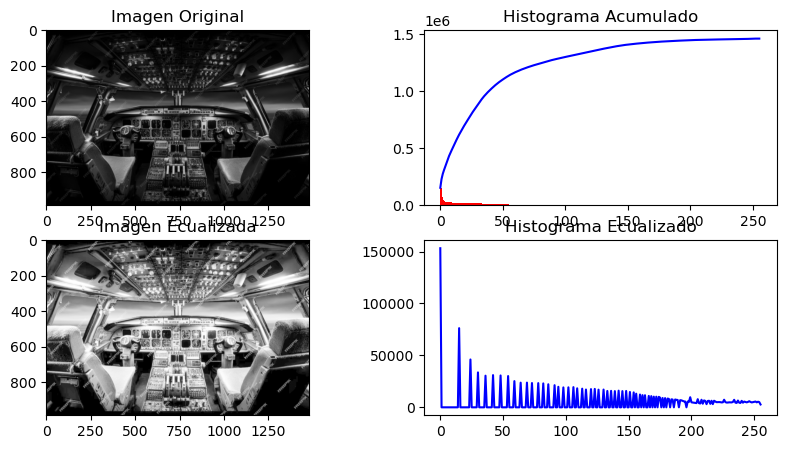

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img=cv2.imread('imagen2.jpg', 0)
histograma,calc=np.histogram(img.flatten(), 256, [0, 256])
distAcum= histograma.cumsum()
dis_norm= distAcum * histograma.max()/distAcum.max()
ecualizar=cv2.equalizeHist(img)
histograma_equ,_= np.histogram(ecualizar.flatten(), 256, [0, 256])

plt.figure(figsize=(10, 5))
plt.subplot(2,2,1)
plt.imshow(img, cmap='gray')
plt.title('Imagen Original')

plt.subplot(2,2,2)
plt.plot(distAcum, color='blue')
plt.hist(img.flatten(), 256, [0, 256], color='red')
plt.title('Histograma Acumulado')

plt.subplot(2,2,3)
plt.imshow(ecualizar, cmap='gray')
plt.title('Imagen Ecualizada')

plt.subplot(2,2,4)
plt.plot(histograma_equ, color='blue')
plt.title('Histograma Ecualizado')

plt.show()

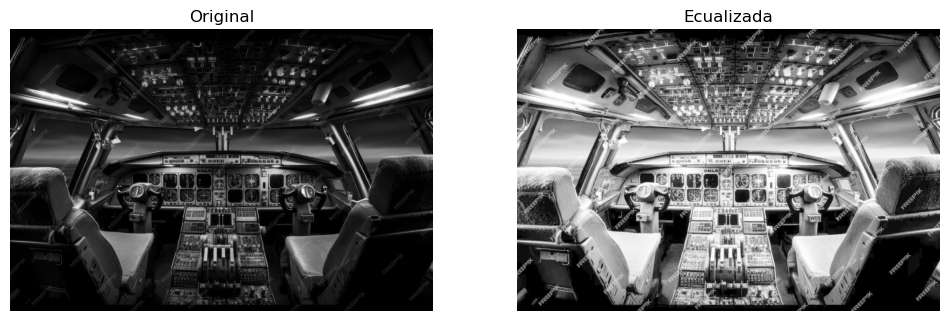

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


img = cv2.imread('imagen2.jpg', 0) 
if img is None:
    raise FileNotFoundError("No se encontró 'imagen2.jpg'.")

ecualizada = cv2.equalizeHist(img)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title('Original')
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title('Ecualizada')
plt.imshow(ecualizada, cmap='gray')
plt.axis('off')

plt.show()

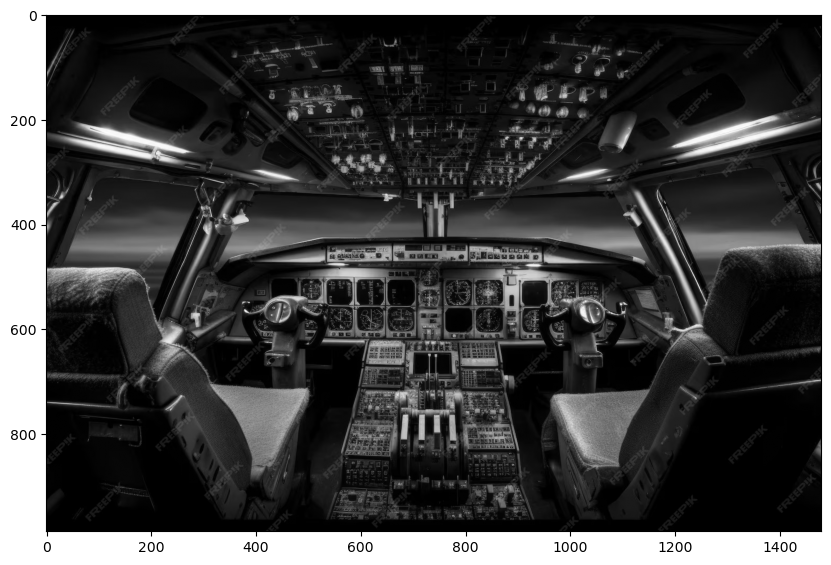

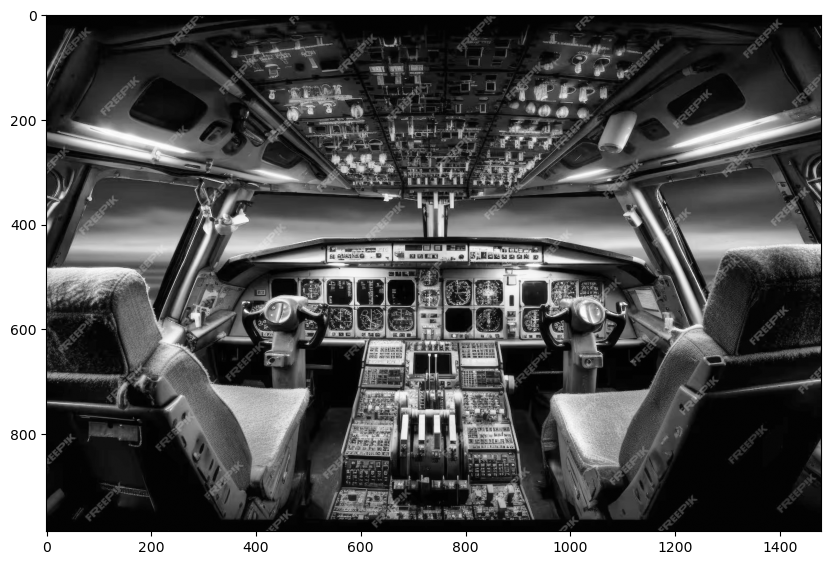

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img=cv2.imread('imagen2.jpg', 0)
clip=2.0
clahe=cv2.createCLAHE(clipLimit=clip, tileGridSize=(8,8))
ecualizado=clahe.apply(img)
plt.imshow(img, cmap='gray')
plt.show()
plt.imshow(ecualizado, cmap='gray')
plt.show()

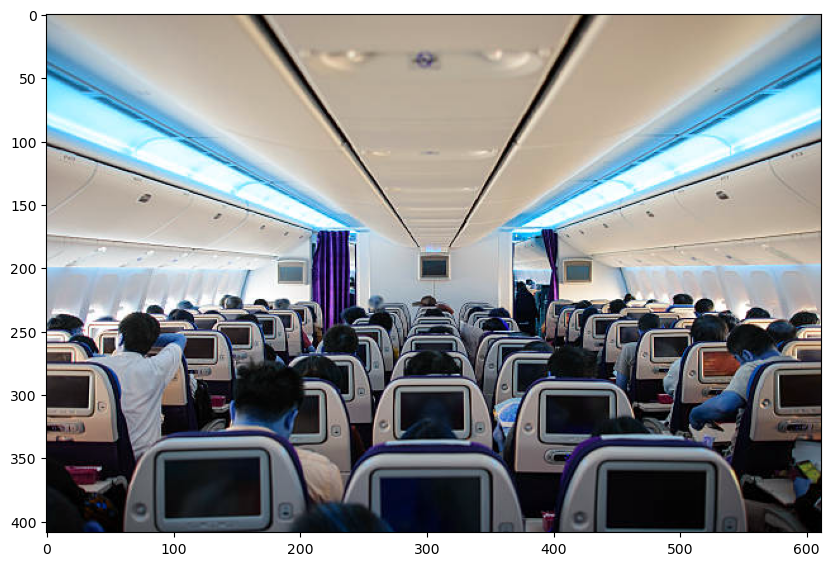

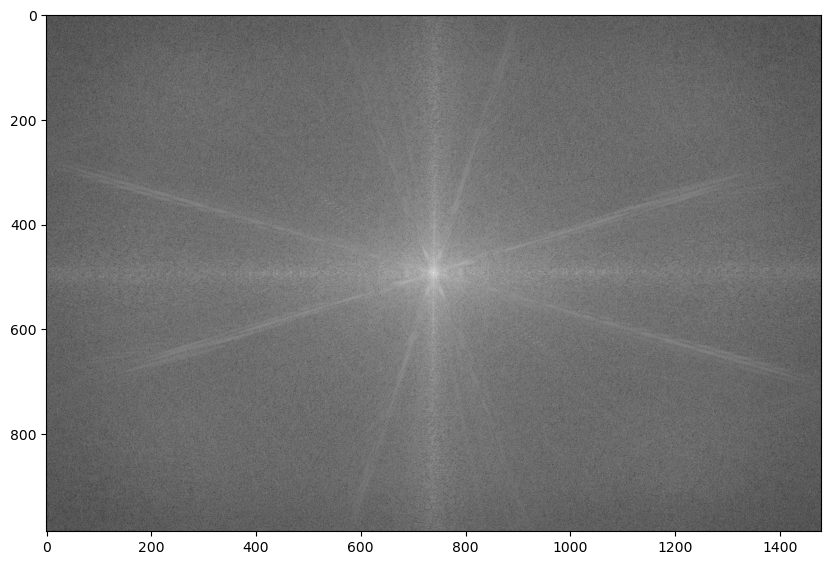

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img=cv2.imread('imagen2.jpg', 0)
transformada=np.fft.fft2(img)
desplazamiento=np.fft.fftshift(transformada)
magnitud_espectro=np.log(1+np.abs(desplazamiento))
plt.imshow(image, cmap='gray')
plt.show()
plt.imshow(magnitud_espectro, cmap='gray')
plt.show()